In [1]:
savecache=0
loadcache=1

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from ciceroscm import input_handler
import pandas as pd
from meteor import MeteorPatternScaling
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")


In [3]:
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")


Getting a datagetter to get CMIP6 data from the zarrstore for tas and pr

In [4]:
expts=["piControl", "abrupt-4xCO2", "historical","ssp585", "ssp245","ssp126"]
expts.index('historical')

2

In [5]:
flds = ["tas", "pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "1pctCO2", "historical","ssp585", "ssp245","ssp126"], flds = flds, dbe=['CMIP','CMIP','CMIP','CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP'])
# This list now holds all the models with complete data for a single ensemble member for the given experiments and fields
models = data_getter.models
# For the purposes of this notebook we limit the use to looking at two coarse resolution models:
# 'ACCESS-ESM1-5',
models=['CanESM5']


Getting some data that can be used by the forcer engine and ciceroscm

In [6]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
#read in SSP245 concentrations and emissions

scenarios = ["ssp126","ssp245","ssp585"]

conc_data=[]
em_data=[]
for i,s in enumerate(scenarios):
    conc_data.append(input_handler.read_inputfile(
    os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")
    ))

    em_data.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

Getting training data to use for predictions:

In [7]:
if not loadcache:
    test_data={}
    for m in models:
        print(m)
        test_data[m] = {

            "base": data_getter.make_meteor_training_data("base", m), #control simulation
            "co2x4": data_getter.make_meteor_training_data("co2x4", m), #co2 only response
            "1pc": data_getter.make_meteor_training_data("1pc", m)} #co2 only response
            
        for s in scenarios:
                test_data[m][s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], m
                    )


In [8]:
if savecache:
    cachedir = os.path.join(os.getcwd(), "cache")
    if not os.path.exists(cachedir):
        os.makedirs(cachedir)
    for m in models:
        for k in test_data[m]:
            test_data[m][k].to_netcdf(
                os.path.join(cachedir, f"{m}_{k}_test_data.nc")
            )

In [9]:
if loadcache:
    cachedir = os.path.join(os.getcwd(), "cache")

    test_data={}
    for m in models:
        test_data[m] = {
            "base": xr.open_dataset(
                os.path.join(cachedir, f"{m}_base_test_data.nc")
            ),
            "co2x4": xr.open_dataset(
                os.path.join(cachedir, f"{m}_co2x4_test_data.nc")
            ),
            "1pc": xr.open_dataset(
                os.path.join(cachedir, f"{m}_1pc_test_data.nc")
            ),
        }
        for s in scenarios:
            test_data[m][s] = xr.open_dataset(
                os.path.join(cachedir, f"{m}_{s}_test_data.nc")
            )
        
        

Let's use SSP245 as the anomaly experiment

In [10]:
for m in models:
    test_data[m]["sulxanom"]=test_data[m]["ssp245"]

Making patterns one with just co2x4, and one including the sulfate from residual in the experiment. The fisrt will include just base (piControl) and co2x4 (abrupt4xCO2), the second will also have a sulxanom which we take from the historical and ssp245 composite experiment

First encode the pure CO2 response

In [11]:
%%capture
ghg_pattern = {}
for m in models:
    ghg_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-ghg",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )

Now encode a set of patterns, including the historical/future composite

In [12]:
%%capture
anomsulf_pattern = {}
for m in models:
    anomsulf_pattern[m] = MeteorPatternScaling(
            "cmip6-"+m+"-anomsulf",
            {"tas": 2, "pr": 2},
            lambda key: test_data[m][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

Then taking the data from the ssp-data for ciceroscm and making predictions

In [13]:
%%capture
patterns_ghg={}
patterns_anomsulf={}
for m in models:
    patterns_ghg[m]={}
    patterns_anomsulf[m]={}

    for i,s in enumerate(scenarios):
        patterns_ghg[m][s]=(ghg_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )
        patterns_anomsulf[m][s]=(anomsulf_pattern[m].predict_from_combined_experiment(
            em_data[i], conc_data[i], ["pr", "tas"])
        )

Plotting global means for the CMIP6 data, the pattern with all forcing as CO2, and the pattern from including the aerosol residual as obtained above

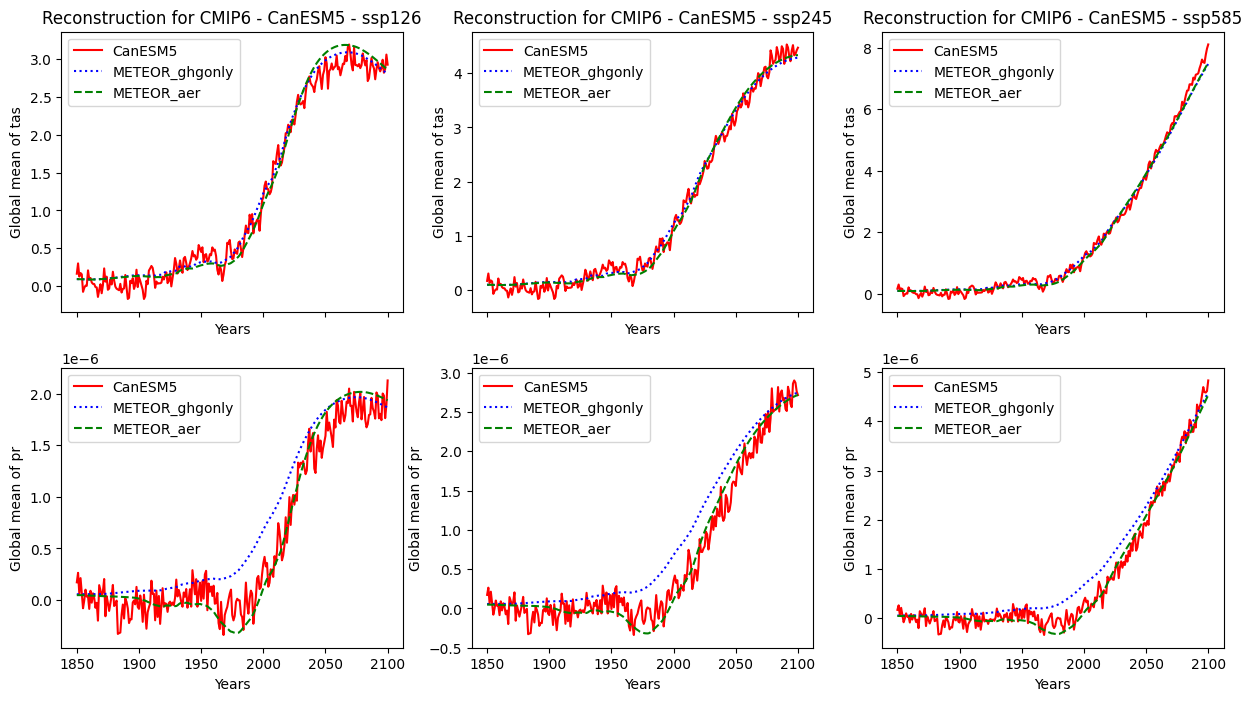

In [14]:
# NBVAL_IGNORE_OUTPUT
fig, axs = plt.subplots(nrows=len(flds), ncols=len(scenarios), sharex=True,figsize=(15,8))
m="CanESM5"
for i,s in enumerate(scenarios):
    for j, fld in enumerate(flds):
        zero_val = np.mean(prpatt.global_mean(test_data[m]["base"][fld]).values)
        total_years = len(test_data[m]["sulxanom"][fld]["year"].values)
        years_to_plot = range(1850,1850+total_years)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(test_data[m][s][fld]).values[0,:]-zero_val, color="red", label=m)
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_ghg[m][s][fld]).values[100:], color="blue", label="METEOR_ghgonly",linestyle=':')
        axs[j,i].plot(years_to_plot, prpatt.global_mean(patterns_anomsulf[m][s][fld]).values[100:], color="green", label="METEOR_aer",linestyle='--')
        axs[j,i].set_xlabel("Years")
        if j == 0:
            axs[j,i].set_title(f"Reconstruction for CMIP6 - "+m+" - "+s)
        axs[j,i].set_ylabel(f"Global mean of {fld}")
        axs[j,i].legend()

# Testing METEOR Monthly Noise Generation



In [15]:

# 1. Generate a climate realization for a specific warming scenario
years = years_to_plot
# Create a plausible warming trajectory: 1.2°C in 2020 to 2.5°C in 2050
fld='tas'
m='CanESM5'
s='ssp245'
meteor_out=patterns_anomsulf[m][s][fld]
warming_trajectory = prpatt.global_mean(meteor_out).values
monthly_warming = np.repeat(warming_trajectory, 12)


Use case 1: use internally-calculated global mean temperature from original ESM simulation to train noise model (default behaviour of train_model)

In [16]:
target=data_getter.make_meteor_training_data_composite(
                        ["historical", s], m,monthly=True
                    )

In [17]:
zero_val = np.mean(prpatt.global_mean(test_data[m]["base"][fld]).values)


In [18]:

org_tas_frac = prpatt.global_mean(target['tas'])-zero_val
org_tas_frac = org_tas_frac.assign_coords(
    year=("month", np.arange(org_tas_frac.shape[1]) / 12 + 1850)
)
org_tas_frac = org_tas_frac.swap_dims({"month": "year"})
org_tas_frac = org_tas_frac.drop_vars("month")#-zero_val

In [19]:
meteor_out=prpatt.global_mean(anomsulf_pattern[m].to_monthly(patterns_anomsulf[m][s][fld], start_year=0))[1200:]

Mode 1: direct train from data (no specified global timeseries), PCA only with no METEOR climatology.

Mode 2: specified global timeseries, noiseonly with METEOR climatology.


In [20]:

# Train a noise model using the new integrated approach
tas_noise_model = data_getter.train_noise_model(
    experiments=["historical", "ssp245"], 
    model="CanESM5", 
    variable_name="tas",
    n_modes=8, 
    lag_order=2,
    custom_global_temp=monthly_warming[1200:],
    use_picontrol_baseline=True,
    cache_dir="./noise_cache"
)

   Fetched piControl baseline for CanESM5 tas: 277.331
✅ Noise generator fitted successfully.
   - PCA modes: 8
   - Variance explained: 45.77%
   - VARX lag order: 2
Model saved to ./noise_cache/CanESM5_tas_noise_model.pkl


In [21]:


n_realizations = 20
realizations = []
global_mean=np.zeros((n_realizations,len(monthly_warming)))
for i in range(n_realizations):
    realization = tas_noise_model.generate_realization(
        monthly_warming, 
        noise_only=True, 
        random_seed=42 + i  # Different seed for each realization
    )
    realizations.append(realization)
    global_mean[i,:]=prpatt.global_mean(realization)


global_mean_xr = xr.DataArray(
    global_mean[:,1200:],
    coords={
        "year": np.arange(global_mean.shape[1])[:-1200]/12+1850,
        "realization": np.arange(global_mean.shape[0]),
    },
    dims=("realization","year"),
)
            

/var/folders/pd/218my53900s1gy0k6lcyvjxm0000gn/T/ipykernel_45724/1025941009.py:9: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend([p, p2, p3], ['METEOR_noise','METEOR monthly','Original model'])


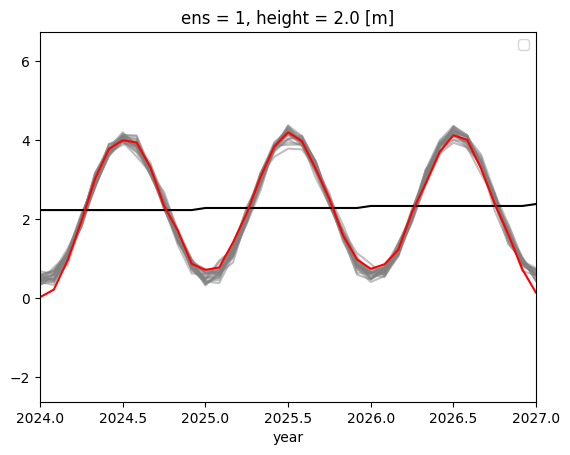

In [22]:


for i in range(n_realizations):
    p=plt.plot(global_mean_xr.year, meteor_out.values + global_mean_xr[i,:], color='grey',alpha=0.5,label='METEOR_noise')

p2=(meteor_out.values + global_mean_xr[0,:]*0).plot(label='METEOR monthly',color='black')
p3=org_tas_frac.plot(label='Original model',color='red')

plt.xlim((2024, 2027))

plt.legend([p, p2, p3], ['METEOR_noise','METEOR monthly','Original model'])

(0.0, 24.0)

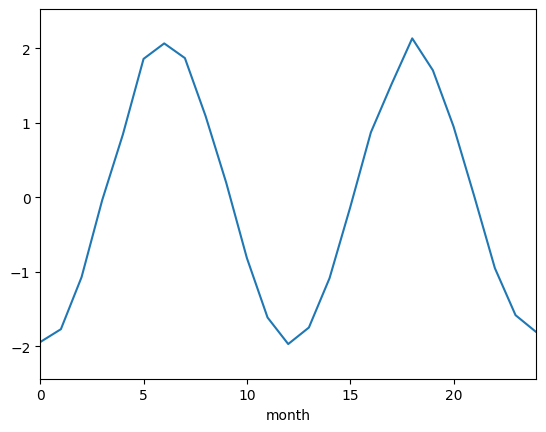

In [90]:
prpatt.global_mean(realizations[0]).plot()
plt.xlim((0,24))

In [37]:
tmp=test_data[m][s][fld]


# Interpolate 'tmp' from yearly to monthly intervals using linear interpolation
tmp_monthly = tmp.interp(
    year=np.arange(tmp.year.values[0], tmp.year.values[-1] + 1/12, 1/12),
    method="linear"
)
tmp_monthly = tmp_monthly.assign_coords(month=("year", np.arange(tmp_monthly.sizes["year"])))
tmp_monthly = tmp_monthly.swap_dims({"year": "month"})
tmp_monthly = tmp_monthly.drop_vars("year")

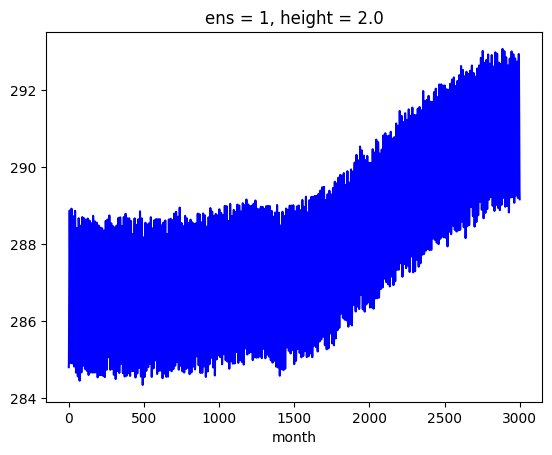

In [42]:
full_projection=realizations[0]+tmp_monthly
prpatt.global_mean(full_projection).plot(label='METEOR_noise+monthly',color='blue')

In [115]:
def calculate_degree_days(
    monthly_mean_temps,
    base_temperature=18.0,
    sigma_m_c1=1.45,
    sigma_m_c2=0.29,
    sigma_m_c3=0.664,
    a_val_c1=1.698
):
    """
    Calculates Heating Degree Days (HDD) and Cooling Degree Days (CDD) from
    an xarray.DataArray of monthly mean temperatures.

    This function implements the methodology described in Isaac and van Vuuren (2009),
    which uses a correction formula from Erbs et al. (1983) to account for
    daily temperature variations. It processes the entire DataArray using
    vectorized operations.

    Args:
        monthly_mean_temps (xr.DataArray): An xarray DataArray with a 'month'
                                           dimension containing average monthly
                                           temperatures in Celsius. The coordinate
                                           for 'month' should be an integer index
                                           (e.g., 0, 1, 2, ...).
        base_temperature (float): The base temperature in Celsius at which neither
                                  heating nor cooling is needed. Defaults to 18.0°C.
        sigma_m_c1 (float): Coefficient c1 for the σ_m calculation. Default is 1.45.
        sigma_m_c2 (float): Coefficient c2 for the σ_m calculation. Default is 0.29.
        sigma_m_c3 (float): Coefficient c3 for the σ_m calculation. Default is 0.664.
        a_val_c1 (float): Coefficient for the 'a' value calculation. Default is 1.698.

    Returns:
        tuple: A tuple of xarray.DataArray objects containing:
            - monthly_hdd (xr.DataArray): Monthly HDD values.
            - monthly_cdd (xr.DataArray): Monthly CDD values.
            - total_hdd (xr.DataArray): Annual total HDD.
            - total_cdd (xr.DataArray): Annual total CDD.
    """
    if not isinstance(monthly_mean_temps, xr.DataArray):
        raise TypeError("Input must be an xarray.DataArray.")

    # Assume the time dimension is always named 'month'
    if 'month' not in monthly_mean_temps.dims:
        raise ValueError("Input DataArray must have a dimension named 'month'.")

    # Group by calendar month using the modulo operator
    month_grouper = monthly_mean_temps['month'] % 12
    monthly_clim = monthly_mean_temps.groupby(month_grouper).mean(dim='month')

    # Warn if the climatology is built from less than a full year's data
    if len(monthly_clim.month) < 12:
        warnings.warn(
            "Input data covers less than a full 12-month cycle. "
            "The standard deviation of monthly temperatures (sigma_y) is calculated "
            "from an incomplete year, which may affect the accuracy of the "
            "degree-day estimation.",
            UserWarning
        )

    sigma_y = monthly_clim.std(dim='month')

    # Get the number of days in each month assuming a standard non-leap year
    days_in_month_map = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    calendar_month_indices = monthly_mean_temps['month'] % 12
    days_in_month = xr.DataArray(
        days_in_month_map[calendar_month_indices.values],
        coords={'month': monthly_mean_temps['month']},
        dims=['month']
    )


    # --- Vectorized implementation of Equation 5 ---

    # σ_m = c1 - c2*T_a + c3*σ_y
    sigma_m = sigma_m_c1 - (sigma_m_c2 * monthly_mean_temps) + (sigma_m_c3 * sigma_y)

    # a = c1_a * sqrt(D_m)
    a_val = a_val_c1 * np.sqrt(days_in_month)

    # h = |T_base - T_a| / (σ_m * sqrt(D_m))
    h_val = np.abs(base_temperature - monthly_mean_temps) / (sigma_m * np.sqrt(days_in_month))

    # The core of the equation, handling potential overflow
    # For large x, log(exp(-x) + exp(x)) -> log(exp(x)) -> x
    # The term then becomes h/2 + (a*h)/(2a) = h
    x = a_val * h_val
    term_in_brackets = xr.where(
        x > 100,
        h_val,
        (h_val / 2) + (np.log(np.exp(-x) + np.exp(x))) / (2 * a_val)
    )

    # DD_m = σ_m * (D_m)^1.5 * [term]
    degree_days_m = sigma_m * (days_in_month ** 1.5) * term_in_brackets

    # Assign to HDD or CDD based on temperature relative to the base
    monthly_hdd = xr.where(monthly_mean_temps < base_temperature, degree_days_m, 0)
    monthly_cdd = xr.where(monthly_mean_temps > base_temperature, degree_days_m, 0)

    monthly_hdd.name = "HDD"
    monthly_cdd.name = "CDD"

    # Group by year using integer division
    annual_grouper = monthly_mean_temps['month'] // 12
    total_hdd = monthly_hdd.groupby(annual_grouper).sum(dim='month')
    total_hdd.name = "Annual_HDD"
    total_cdd = monthly_cdd.groupby(annual_grouper).sum(dim='month')
    total_cdd.name = "Annual_CDD"


    return monthly_hdd, monthly_cdd, total_hdd, total_cdd



In [111]:
full_projection.month.size/12

250.16666666666666

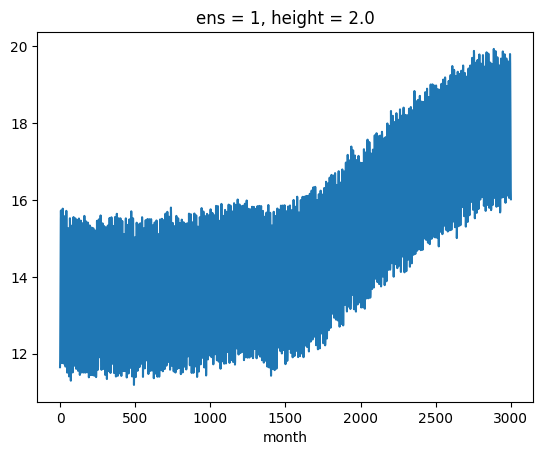

In [119]:
prpatt.global_mean(full_projection-273.15).plot()

In [120]:
(monthly_hdd, monthly_cdd, total_hdd, total_cdd)=calculate_degree_days(full_projection-273.15)

/Users/bensan/Documents/Github/METEOR/venv/lib/python3.9/site-packages/xarray/core/computation.py:821: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


In [121]:

oslo_lat = 59.91
oslo_lon = 10.75

lat_idx = np.abs(monthly_hdd.lat - oslo_lat).argmin().item()
lon_idx = np.abs(monthly_hdd.lon - oslo_lon).argmin().item()

oslo_tas = full_projection.isel(lat=lat_idx, lon=lon_idx, ens=0)
oslo_cdd = monthly_cdd.isel(lat=lat_idx, lon=lon_idx, ens=0)
oslo_hdd = monthly_hdd.isel(lat=lat_idx, lon=lon_idx, ens=0)

oslo_cdd

<xarray.DataArray 'CDD' (month: 3002)> Size: 24kB
array([0., 0., 0., ..., 0., 0., 0.])
Coordinates:
  * month    (month) int64 24kB 0 1 2 3 4 5 6 ... 2996 2997 2998 2999 3000 3001
    lat      float64 8B 60.0
    lon      float64 8B 11.25
    ens      int64 8B 1
    height   float64 8B 2.0

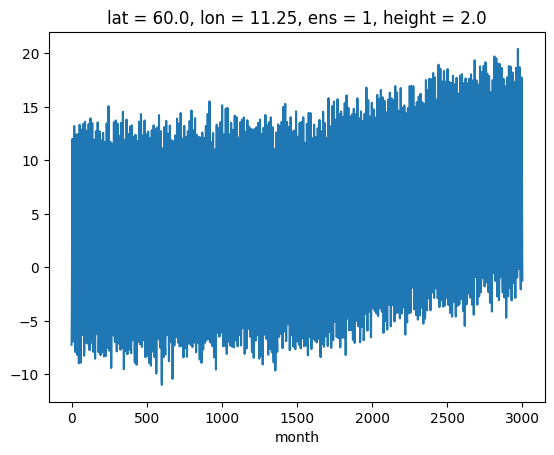

In [122]:
(oslo_tas-273.15).plot()


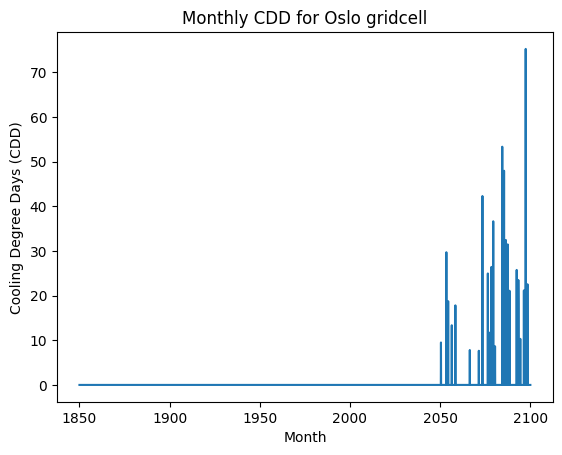

In [137]:
# Plot the monthly CDD for Oslo
plt.plot(1850+oslo_hdd.month/12, oslo_cdd)
plt.title("Monthly CDD for Oslo gridcell")
plt.xlabel("Month")
plt.ylabel("Cooling Degree Days (CDD)")
plt.show()

(1990.0, 2100.0)

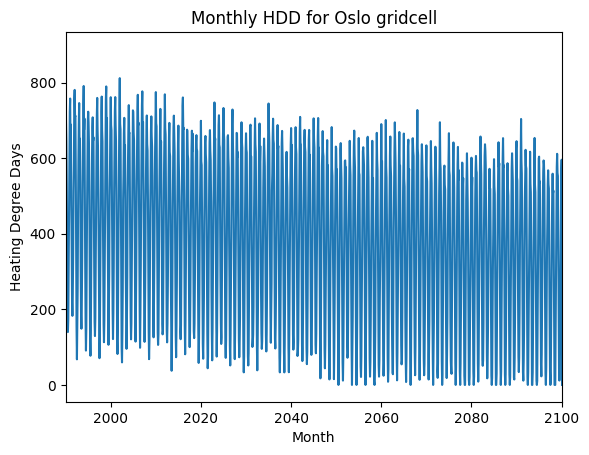

In [141]:
# Plot the monthly HDD for Oslo
plt.plot(1850+oslo_hdd.month/12, oslo_hdd)
plt.title("Monthly HDD for Oslo gridcell")
plt.xlabel("Month")
plt.ylabel("Heating Degree Days")
plt.xlim(1990,2100)

In [ ]:
monthly_cdd